# 02 · Análisis exploratorio de datos (EDA)

**Proyecto:** Identificación de hogares en situación de pobreza monetaria mediante aprendizaje automático (ENAHO 2025).

Este cuaderno continúa la **Fase 2 de CRISP-DM** con el análisis exploratorio. No buscamos todavía entrenar modelos, sino **entender qué características del hogar se relacionan con la pobreza** y reunir evidencia para las decisiones de preparación y modelado.

Cada gráfico responde a la pregunta: **¿qué evidencia proporciona?**

**Entrada:** el dataset de hogares 2025 del cuaderno 01 y el módulo de programas sociales de la ENAHO. **Salida:** las figuras del análisis (`results/figuras/`).

Contenido:

1. distribución de la variable objetivo;
2. análisis geográfico: departamento, dominio y área;
3. análisis de categorías: vivienda y servicios;
4. bienes y servicios del hogar según su condición de pobreza;
5. variables numéricas: distribuciones, valores atípicos y correlaciones;
6. evidencia del problema: errores de focalización en programas sociales.

**Nota sobre el análisis temporal:** la ENAHO 2025 es un corte transversal de un solo año, así que no corresponde un análisis de tendencia dentro del dataset. La evolución histórica de la pobreza se toma de las cifras oficiales del INEI en la introducción del informe.

In [1]:
# ==========================================================
# CONFIGURACIÓN DEL ENTORNO (funciona en Google Colab y en local)
# ==========================================================
# En Colab, la primera vez conviene instalar las versiones del proyecto y reiniciar la sesión:
# !pip install -r /content/drive/MyDrive/proyecto-pobreza-ia/requirements.txt
import os
import sys

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    # En Colab: montamos Google Drive y nos ubicamos en la carpeta del proyecto
    from google.colab import drive
    drive.mount("/content/drive")
    RUTA_PROYECTO = "/content/drive/MyDrive/proyecto-pobreza-ia"  # ajustar si el proyecto está en otra carpeta
    os.chdir(RUTA_PROYECTO)
elif os.path.basename(os.getcwd()) == "notebooks":
    # En local: si el notebook se abre desde la carpeta notebooks/, subimos a la raíz
    os.chdir("..")

# Comprobamos que estamos en la raíz del proyecto y permitimos importar su código (carpeta src/)
assert os.path.isdir("src"), "No se encuentra la carpeta src/: revisa RUTA_PROYECTO"
sys.path.insert(0, os.getcwd())
print("Entorno:", "Google Colab" if EN_COLAB else "local", "| Carpeta del proyecto:", os.path.basename(os.getcwd()))

Entorno: local | Carpeta del proyecto: proyecto-pobreza-ia


In [2]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Código propio del proyecto (carpeta src/)
from src.data.cargar import cargar_modulos
from src.data.descargar import descargar_enaho
from src.features.construir import ETIQUETAS, CLAVES_HOGAR, VARIABLES_NUMERICAS, VARIABLES_BINARIAS
from src.visualizacion import (
    aplicar_estilo, guardar_figura, COLOR_POBRE, COLOR_NO_POBRE, COLORES_CLASE, NOMBRES_CLASE, TEXTO_SECUNDARIO,
)

aplicar_estilo()

# Dataset de hogares construido en el cuaderno 01
hogares = pd.read_csv("data/processed/hogares_enaho_2025.csv", dtype={"ubigeo": str})
print("Hogares:", hogares.shape)

Hogares: (33702, 43)


In [3]:
def tasa_pobreza_personas(grupo):
    # Porcentaje de PERSONAS pobres en el grupo (ponderado con factor de expansión × miembros)
    peso = grupo["factor07"] * grupo["n_miembros"]
    return (grupo["pobre"] * peso).sum() / peso.sum() * 100


def tasa_por_categoria(df, variable):
    # Porcentaje de HOGARES pobres por categoría (sin ponderar, como los ve el modelo)
    tabla = df.groupby(variable)["pobre"].agg(hogares="size", porcentaje_pobres="mean")
    tabla["porcentaje_pobres"] = (tabla["porcentaje_pobres"] * 100).round(1)
    if variable in ETIQUETAS:
        tabla.index = tabla.index.map(ETIQUETAS[variable])
    return tabla.sort_values("porcentaje_pobres", ascending=False)


TASA_HOGARES = hogares["pobre"].mean() * 100
TASA_PERSONAS = tasa_pobreza_personas(hogares)
print(f"Hogares pobres: {TASA_HOGARES:.1f} %  |  Personas pobres: {TASA_PERSONAS:.1f} %")

Hogares pobres: 18.1 %  |  Personas pobres: 25.7 %


Usaremos dos tipos de porcentaje, y conviene no confundirlos:

- **Porcentaje de personas pobres** (ponderado con el factor de expansión): es el indicador oficial y sirve para describir el problema en el país.
- **Porcentaje de hogares pobres** (sin ponderar): es lo que el modelo "ve", porque cada fila es un hogar de la muestra.

## 1. Distribución de la variable objetivo

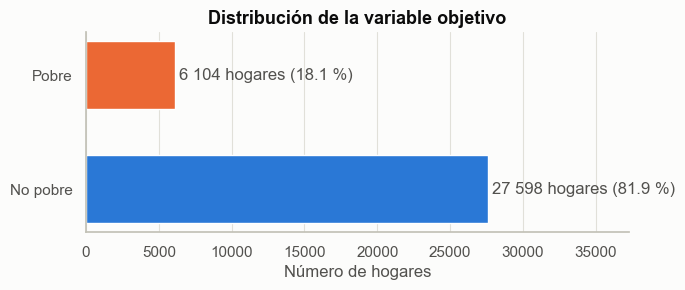

In [4]:
conteo = hogares["pobre"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 2.6))
barras = ax.barh([NOMBRES_CLASE[c] for c in conteo.index], conteo.values,
                 color=[COLORES_CLASE[c] for c in conteo.index], height=0.6)
for barra, valor in zip(barras, conteo.values):
    ax.text(valor + 300, barra.get_y() + barra.get_height() / 2,
            f"{valor:,} hogares ({valor / conteo.sum() * 100:.1f} %)".replace(",", " "),
            va="center", color=TEXTO_SECUNDARIO)
ax.set_xlim(0, conteo.max() * 1.35)
ax.set_xlabel("Número de hogares")
ax.set_title("Distribución de la variable objetivo")
ax.grid(axis="y", visible=False)
guardar_figura("02_distribucion_objetivo")
plt.show()

### ¿Qué evidencia proporciona este gráfico?

- El dataset tiene **6 104 hogares pobres (18,1 %)** y **27 598 no pobres (81,9 %)**. Hay aproximadamente 1 hogar pobre por cada 4,5 no pobres.
- El **desbalance es moderado**: no es un caso extremo como la detección de fraude, pero sí suficiente para que el *accuracy* sea engañoso. Un modelo que prediga siempre "no pobre" tendría 81,9 % de accuracy sin identificar a ningún hogar pobre.
- **Decisión para el modelado:** usar división **estratificada**, evaluar con *precision*, *recall*, *F1* y *ROC-AUC*, y probar `class_weight="balanced"`.

## 2. Análisis geográfico

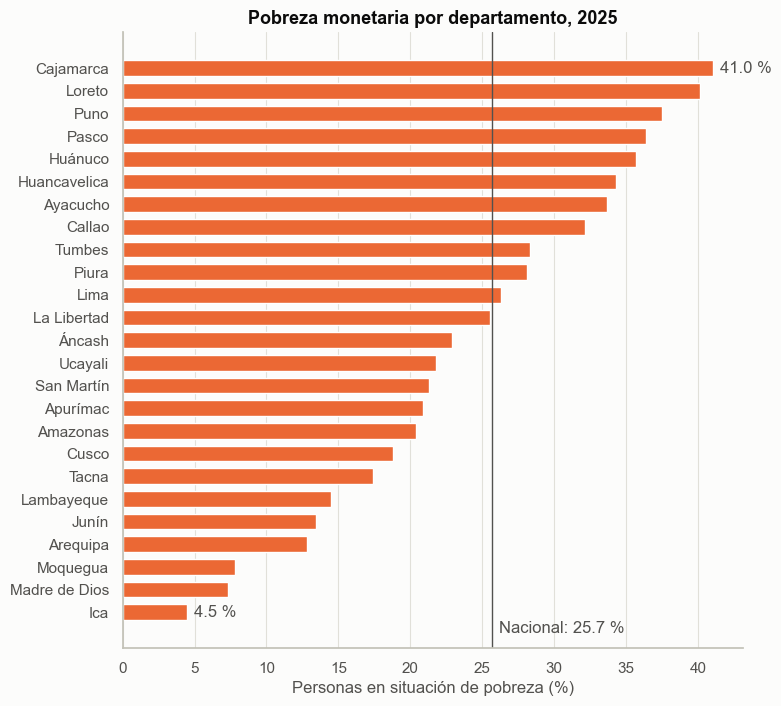

departamento,Cajamarca,Loreto,Puno,Pasco,Huánuco,Huancavelica,Ayacucho,Callao,Tumbes,Piura,...,Apurímac,Amazonas,Cusco,Tacna,Lambayeque,Junín,Arequipa,Moquegua,Madre de Dios,Ica
pobreza_%,41.0,40.1,37.5,36.4,35.7,34.3,33.7,32.1,28.3,28.1,...,20.9,20.4,18.8,17.4,14.5,13.5,12.8,7.8,7.3,4.5


In [5]:
# Porcentaje de personas pobres por departamento (indicador oficial, ponderado)
por_departamento = (hogares.groupby("departamento")[["pobre", "factor07", "n_miembros"]]
                    .apply(tasa_pobreza_personas)
                    .rename(ETIQUETAS["departamento"])
                    .sort_values())

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(por_departamento.index, por_departamento.values, color=COLOR_POBRE, height=0.7)
ax.axvline(TASA_PERSONAS, color=TEXTO_SECUNDARIO, linewidth=1)
ax.text(TASA_PERSONAS + 0.5, -0.9, f"Nacional: {TASA_PERSONAS:.1f} %", color=TEXTO_SECUNDARIO)

# Etiquetamos solo los extremos: el departamento más pobre y el menos pobre
for posicion in (0, len(por_departamento) - 1):
    ax.text(por_departamento.iloc[posicion] + 0.5, posicion, f"{por_departamento.iloc[posicion]:.1f} %",
            va="center", color=TEXTO_SECUNDARIO)

ax.set_xlabel("Personas en situación de pobreza (%)")
ax.set_title("Pobreza monetaria por departamento, 2025")
ax.grid(axis="y", visible=False)
guardar_figura("02_pobreza_departamento")
plt.show()

por_departamento.sort_values(ascending=False).round(1).to_frame("pobreza_%").T

### ¿Qué evidencia proporciona este gráfico?

- La pobreza está **muy desigualmente distribuida en el territorio**: va de **4,5 % en Ica** a **41,0 % en Cajamarca**. Es decir, una persona en Cajamarca tiene nueve veces más probabilidad de ser pobre que una en Ica.
- Los departamentos más pobres (Cajamarca, Loreto, Puno, Pasco, Huánuco, Huancavelica y Ayacucho) son principalmente de **sierra y selva**, pero el problema no es solo rural: **Lima (26,3 %)** y el **Callao (32,1 %)** están por encima del promedio nacional.
- **Decisión para el modelado:** la ubicación aporta información, así que `departamento` y `dominio` entran como variables categóricas. Pero esto obliga a vigilar en la evaluación si el modelo **se equivoca más en algunas regiones que en otras** (análisis de sesgo en el cuaderno 05).

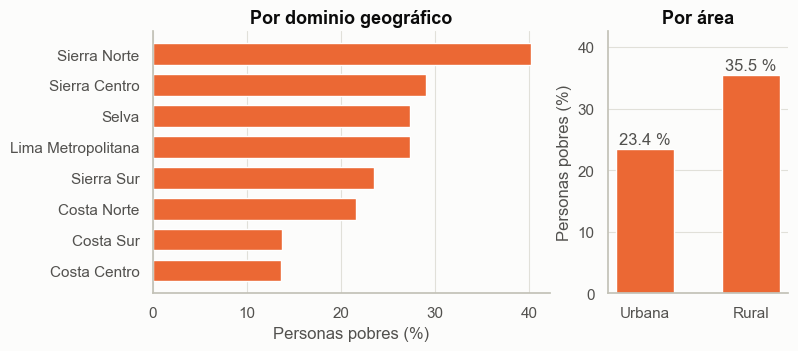

Personas pobres que viven en área urbana: 74.1 %
Hogares pobres de la muestra que son rurales: 50.0 %


In [6]:
por_dominio = (hogares.groupby("dominio")[["pobre", "factor07", "n_miembros"]]
               .apply(tasa_pobreza_personas).rename(ETIQUETAS["dominio"]).sort_values())
por_area = (hogares.groupby("area_rural")[["pobre", "factor07", "n_miembros"]]
            .apply(tasa_pobreza_personas).rename({0: "Urbana", 1: "Rural"}))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.2, 3.4), gridspec_kw={"width_ratios": [2.2, 1]})
ax1.barh(por_dominio.index, por_dominio.values, color=COLOR_POBRE, height=0.7)
ax1.set_title("Por dominio geográfico")
ax1.set_xlabel("Personas pobres (%)")
ax1.grid(axis="y", visible=False)

ax2.bar(por_area.index, por_area.values, color=COLOR_POBRE, width=0.55)
for i, valor in enumerate(por_area.values):
    ax2.text(i, valor + 0.8, f"{valor:.1f} %", ha="center", color=TEXTO_SECUNDARIO)
ax2.set_title("Por área")
ax2.set_ylabel("Personas pobres (%)")
ax2.set_ylim(0, por_area.max() * 1.2)
ax2.grid(axis="x", visible=False)

guardar_figura("02_pobreza_dominio_area")
plt.show()

# ¿Dónde vive la población pobre? (personas, ponderado)
peso = hogares["factor07"] * hogares["n_miembros"]
personas_pobres = hogares["pobre"] * peso
print(f"Personas pobres que viven en área urbana: {personas_pobres[hogares['area_rural'] == 0].sum() / personas_pobres.sum() * 100:.1f} %")
print(f"Hogares pobres de la muestra que son rurales: {hogares.loc[hogares['pobre'] == 1, 'area_rural'].mean() * 100:.1f} %")

### ¿Qué evidencia proporciona este gráfico?

- Por dominio, la **Sierra Norte (40,2 %)** concentra la mayor pobreza, seguida por la Sierra Centro (29,0 %), y la Selva y Lima Metropolitana (27,3 % cada una). La Costa Centro (13,6 %) y la Costa Sur (13,8 %) tienen las tasas más bajas.
- La pobreza **rural (35,5 %)** es mayor que la **urbana (23,4 %)**. Sin embargo, el **74,1 % de las personas pobres vive en zonas urbanas**, porque ahí vive la mayoría de la población. La pobreza en el Perú es mayoritariamente urbana en número de personas.
- En la muestra, solo la **mitad (50,0 %) de los hogares pobres es rural**. Por eso, una regla "rural = pobre" dejaría fuera a la otra mitad desde el inicio.
- **Evidencia clave para el baseline:** si esa regla fuera suficiente, no haría falta un modelo. Será el **baseline sin IA** del proyecto, y el modelo deberá superarla con claridad para justificar el uso de IA.

## 3. Análisis de categorías: vivienda y servicios

Calculamos el porcentaje de **hogares** pobres dentro de cada categoría. La línea vertical marca el promedio de la muestra (18,1 %). Para evitar conclusiones basadas en muy pocos casos, en los gráficos mostramos solo las categorías con al menos 100 hogares. Las tablas incluyen todas.

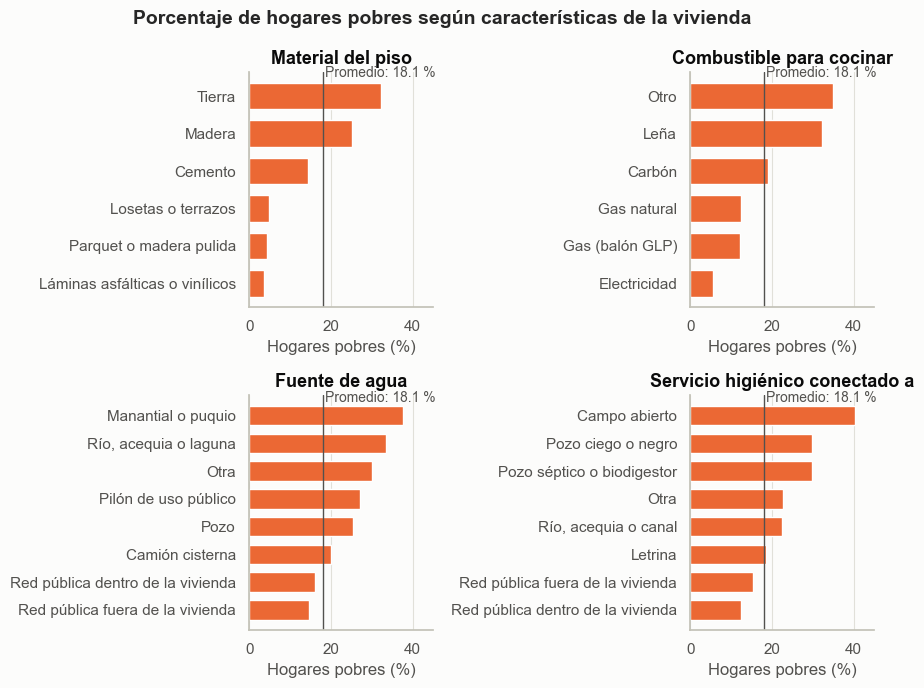

In [7]:
variables_vivienda = {
    "material_piso": "Material del piso",
    "combustible_cocina": "Combustible para cocinar",
    "fuente_agua": "Fuente de agua",
    "desague": "Servicio higiénico conectado a",
}

fig, ejes = plt.subplots(2, 2, figsize=(9, 7))
for ax, (variable, titulo) in zip(ejes.flat, variables_vivienda.items()):
    tabla = tasa_por_categoria(hogares, variable)
    tabla = tabla[tabla["hogares"] >= 100].sort_values("porcentaje_pobres")
    ax.barh(tabla.index, tabla["porcentaje_pobres"], color=COLOR_POBRE, height=0.7)
    ax.axvline(TASA_HOGARES, color=TEXTO_SECUNDARIO, linewidth=1)
    ax.text(TASA_HOGARES + 0.5, len(tabla) - 0.5, f"Promedio: {TASA_HOGARES:.1f} %", color=TEXTO_SECUNDARIO, fontsize=10)
    ax.set_title(titulo)
    ax.set_xlabel("Hogares pobres (%)")
    ax.set_xlim(0, 45)
    ax.grid(axis="y", visible=False)

fig.suptitle("Porcentaje de hogares pobres según características de la vivienda", fontsize=14, fontweight="bold")
fig.tight_layout()
guardar_figura("02_pobreza_vivienda")
plt.show()

In [8]:
# Tablas completas (vista de tabla de los gráficos anteriores)
for variable in variables_vivienda:
    print(f"\n{variable}")
    display(tasa_por_categoria(hogares, variable))


material_piso


,hogares,porcentaje_pobres
material_piso,,
Otro,40,32.5
Tierra,8967,32.2
Madera,2865,25.1
Cemento,14639,14.3
Losetas o terrazos,4663,4.7
Parquet o madera pulida,744,4.3
Láminas asfálticas o vinílicos,1415,3.5



combustible_cocina


,hogares,porcentaje_pobres
combustible_cocina,,
Otro,2177,35.0
Leña,6782,32.3
Carbón,262,19.1
Gas natural,3086,12.5
Gas (balón GLP),19748,12.1
Electricidad,357,5.6



fuente_agua


,hogares,porcentaje_pobres
fuente_agua,,
Manantial o puquio,838,37.6
"Río, acequia o laguna",896,33.6
Otra,1112,30.0
Pilón de uso público,666,27.0
Pozo,689,25.3
Camión cisterna,1047,20.1
Red pública dentro de la vivienda,27483,16.2
Red pública fuera de la vivienda,971,14.6



desague


,hogares,porcentaje_pobres
desague,,
Campo abierto,1308,40.4
Pozo ciego o negro,2835,29.8
Pozo séptico o biodigestor,3060,29.7
Otra,3801,22.7
"Río, acequia o canal",572,22.4
Letrina,818,18.5
Red pública fuera de la vivienda,926,15.3
Red pública dentro de la vivienda,20382,12.5


### ¿Qué evidencia proporciona este gráfico?

Las características de la vivienda **separan con claridad** a los hogares con mayor y menor probabilidad de ser pobres:

- **Piso:** el 32,2 % de los hogares con piso de **tierra** es pobre, frente a menos del 5 % de los que tienen losetas, parquet o vinílicos.
- **Combustible:** cocinar con **leña** se asocia a 32,3 % de pobreza, frente a 12,1 % con gas en balón. Es un indicador tanto de ingreso como de acceso a servicios.
- **Agua:** los hogares que se abastecen de **manantial (37,6 %)** o de **río o acequia (33,6 %)** duplican la tasa de los que tienen red pública dentro de la vivienda (16,2 %).
- **Desagüe:** los hogares **sin servicio higiénico** (campo abierto) tienen la tasa más alta: 40,4 %.

Hay un matiz importante: **ninguna categoría supera el 45 %**. Incluso entre los hogares con piso de tierra, dos de cada tres **no** son pobres. **Ninguna variable aislada basta para identificar a los pobres**, lo que justifica un modelo que **combine muchas características**.

In [9]:
for variable in ["material_paredes", "material_techo", "tipo_vivienda", "tenencia_vivienda"]:
    print(f"\n{variable}")
    display(tasa_por_categoria(hogares, variable))


material_paredes


,hogares,porcentaje_pobres
material_paredes,,
Piedra con barro,235,39.1
Tapia,2277,31.5
Adobe,7925,26.0
Madera,3673,25.1
Quincha,393,24.4
Otro,683,23.9
Triplay/calamina/estera,714,23.1
Piedra o sillar con cal o cemento,115,16.5
Ladrillo o bloque de cemento,17318,10.3



material_techo


,hogares,porcentaje_pobres
material_techo,,
Paja u hojas de palmera,411,41.1
Tejas,2089,26.4
Calamina o fibra de cemento,17882,23.2
Madera,379,22.4
Triplay/estera/carrizo,120,20.0
Otro,69,14.5
Caña o estera con torta de barro,894,13.3
Concreto armado,11489,7.8



tipo_vivienda


,hogares,porcentaje_pobres
tipo_vivienda,,
Choza o cabaña,229,43.7
Vivienda improvisada,10,40.0
Casa independiente,30273,18.7
Casa de vecindad,963,14.5
Vivienda en quinta,247,8.9
Departamento en edificio,1610,5.2
Otro,1,0.0



tenencia_vivienda


,hogares,porcentaje_pobres
tenencia_vivienda,,
"Propia, por invasión",1506,19.8
Cedida por otro hogar o institución,5072,19.4
"Propia, totalmente pagada",23843,18.5
Alquilada,2987,13.1
"Propia, comprándola a plazos",144,7.6
Otra forma,55,7.3
Cedida por el trabajo,95,3.2


### Interpretación de las demás variables de vivienda

- **Paredes:** piedra con barro (39,1 %), tapia (31,5 %) y adobe (26,0 %) tienen tasas altas; ladrillo o bloque de cemento, solo 10,3 %.
- **Techo:** paja u hojas de palmera (41,1 %) frente a concreto armado (7,8 %).
- **Tipo de vivienda:** choza o cabaña (43,7 %) frente a departamento en edificio (5,2 %). Algunas categorías tienen muy pocos casos (vivienda improvisada: 10 hogares; "otro": 1 hogar). Al codificarlas con *One-Hot Encoding* aportan poco, pero no causan errores.
- **Tenencia:** es la variable de vivienda que menos discrimina. Las tasas van de 13,1 % a 19,8 % en las categorías con más hogares.

## 4. Bienes y servicios del hogar según la condición de pobreza

Comparamos qué porcentaje de hogares **pobres** y **no pobres** tiene cada bien o servicio.

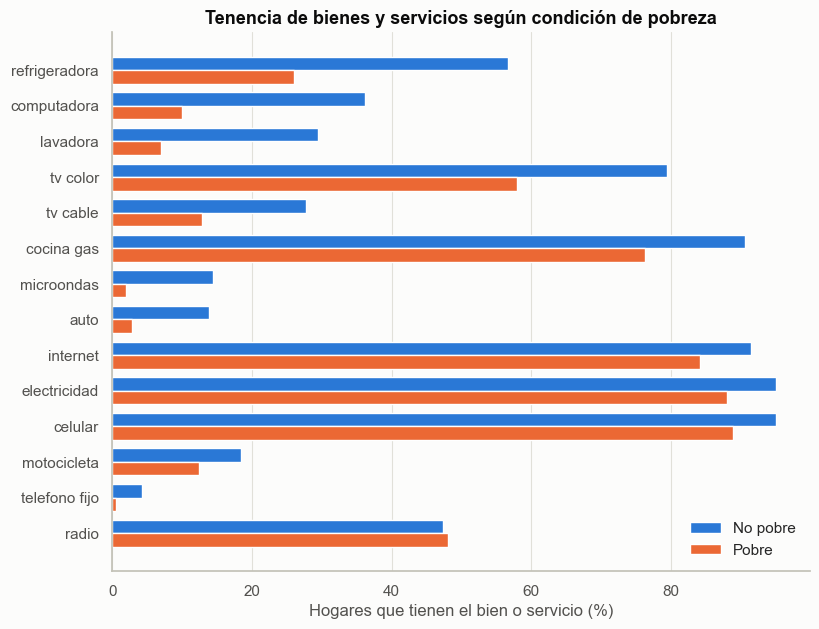

,No pobre,Pobre,diferencia
refrigeradora,56.6,26.1,30.6
computadora,36.2,9.9,26.3
lavadora,29.4,6.9,22.5
tv color,79.5,57.9,21.6
tv cable,27.8,12.8,15.0
cocina gas,90.6,76.3,14.3
microondas,14.5,2.0,12.5
auto,13.9,2.8,11.1
internet,91.5,84.1,7.4
electricidad,95.0,88.1,6.9


In [10]:
bienes = [v for v in VARIABLES_BINARIAS if v not in ("area_rural", "jefe_mujer")]
tenencia = (hogares.groupby("pobre")[bienes].mean().T * 100)
tenencia.columns = [NOMBRES_CLASE[c] for c in tenencia.columns]
tenencia["diferencia"] = tenencia["No pobre"] - tenencia["Pobre"]
tenencia = tenencia.sort_values("diferencia")
tenencia.index = tenencia.index.str.replace("tiene_", "").str.replace("_", " ")

fig, ax = plt.subplots(figsize=(9, 7))
posiciones = np.arange(len(tenencia))
alto = 0.38
ax.barh(posiciones + alto / 2, tenencia["No pobre"], height=alto, color=COLOR_NO_POBRE, label="No pobre")
ax.barh(posiciones - alto / 2, tenencia["Pobre"], height=alto, color=COLOR_POBRE, label="Pobre")
ax.set_yticks(posiciones)
ax.set_yticklabels(tenencia.index)
ax.set_xlabel("Hogares que tienen el bien o servicio (%)")
ax.set_title("Tenencia de bienes y servicios según condición de pobreza")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
guardar_figura("02_bienes_por_clase")
plt.show()

tenencia.sort_values("diferencia", ascending=False).round(1)

### ¿Qué evidencia proporciona este gráfico?

- Los bienes que **más diferencian** a pobres de no pobres son la **refrigeradora** (56,6 % frente a 26,1 %, una diferencia de 30,6 puntos), la **computadora** (36,2 % frente a 9,9 %) y la **lavadora** (29,4 % frente a 6,9 %). Son bienes de costo medio o alto que reflejan capacidad de gasto acumulada.
- Otros servicios están tan extendidos que **discriminan poco**: el celular (95,1 % frente a 88,9 %), la electricidad (95,0 % frente a 88,1 %) e internet (91,5 % frente a 84,1 %).
- La **radio no discrimina**: la tienen el 47,3 % de los no pobres y el 48,0 % de los pobres. Esto se esperaría si el bien es barato y de uso generalizado, y es una advertencia de que **no toda variable intuitiva es informativa**.
- **Decisión para el modelado:** se conservan todas las variables. Los modelos basados en árboles pueden ignorar las poco informativas, y la importancia de variables del cuaderno 05 permitirá confirmarlo.

## 5. Variables numéricas

### Distribución según la condición de pobreza

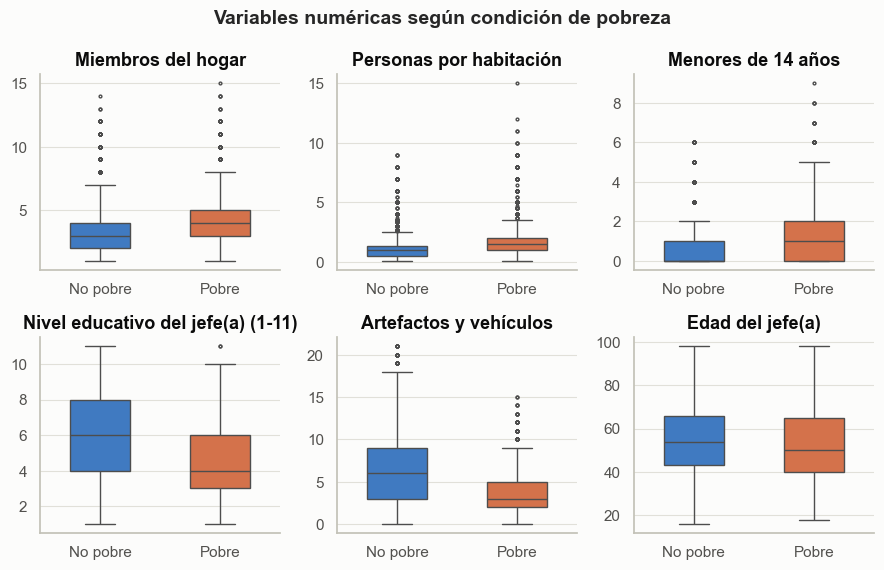

In [11]:
variables_caja = {
    "n_miembros": "Miembros del hogar",
    "personas_por_habitacion": "Personas por habitación",
    "n_menores_14": "Menores de 14 años",
    "educacion_jefe": "Nivel educativo del jefe(a) (1-11)",
    "n_equipos": "Artefactos y vehículos",
    "jefe_edad": "Edad del jefe(a)",
}

datos_caja = hogares.assign(clase=hogares["pobre"].map(NOMBRES_CLASE))
fig, ejes = plt.subplots(2, 3, figsize=(9, 5.8))
for ax, (variable, titulo) in zip(ejes.flat, variables_caja.items()):
    sns.boxplot(data=datos_caja, x="clase", y=variable, hue="clase", order=["No pobre", "Pobre"],
                palette={"No pobre": COLOR_NO_POBRE, "Pobre": COLOR_POBRE}, legend=False,
                width=0.5, linewidth=1, fliersize=2, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(axis="x", visible=False)

fig.suptitle("Variables numéricas según condición de pobreza", fontsize=14, fontweight="bold")
fig.tight_layout()
guardar_figura("02_numericas_boxplot")
plt.show()

In [12]:
# Vista de tabla: media y mediana de cada variable numérica por clase
resumen = hogares.groupby("pobre")[VARIABLES_NUMERICAS].agg(["mean", "median"]).T.round(2)
resumen.columns = [NOMBRES_CLASE[c] for c in resumen.columns]
resumen

No pobre  Pobre
n_miembros              mean        2.99   4.06
                        median      3.00   4.00
n_habitaciones          mean        3.36   2.85
                        median      3.00   3.00
personas_por_habitacion mean        1.08   1.78
                        median      1.00   1.50
jefe_edad               mean       54.52  52.56
                        median     54.00  50.00
n_menores_14            mean        0.55   1.24
                        median      0.00   1.00
n_mayores_65            mean        0.43   0.44
                        median      0.00   0.00
tasa_dependencia        mean        0.61   0.86
                        median      0.50   0.67
educacion_jefe          mean        5.79   4.44
                        median      6.00   4.00
max_educacion_adultos   mean        6.83   5.45
                        median      6.00   6.00
n_equipos               mean        6.25   3.55
                        median      6.00   3.00

### ¿Qué evidencia proporciona este gráfico?

- **Tamaño y composición:** los hogares pobres son más grandes (4,06 miembros en promedio, frente a 2,99) y tienen más menores de 14 años (1,24 frente a 0,55). Tener más dependientes hace que el mismo ingreso se reparta entre más personas.
- **Hacinamiento:** los hogares pobres tienen 1,78 personas por habitación, frente a 1,08 de los no pobres.
- **Educación:** la mediana del nivel educativo del jefe(a) es **4 (primaria completa)** en los hogares pobres y **6 (secundaria completa)** en los no pobres.
- **Equipamiento:** los hogares pobres tienen una mediana de **3 artefactos**, frente a **6** de los no pobres.
- **Edad del jefe(a):** las distribuciones casi se superponen (medianas de 50 y 54 años), así que esta variable discrimina poco por sí sola.
- En todas las variables las cajas **se superponen**: hay hogares pobres con muchos artefactos y hogares no pobres hacinados. De nuevo, **ninguna variable aislada separa las clases**.

### Valores atípicos

In [13]:
# Porcentaje de valores atípicos según la regla del rango intercuartílico (1,5 × IQR)
q1 = hogares[VARIABLES_NUMERICAS].quantile(0.25)
q3 = hogares[VARIABLES_NUMERICAS].quantile(0.75)
iqr = q3 - q1
es_atipico = (hogares[VARIABLES_NUMERICAS] < q1 - 1.5 * iqr) | (hogares[VARIABLES_NUMERICAS] > q3 + 1.5 * iqr)

atipicos = pd.DataFrame({
    "atipicos_%": (es_atipico.mean() * 100).round(1),
    "limite_superior": (q3 + 1.5 * iqr).round(2),
    "maximo": hogares[VARIABLES_NUMERICAS].max(),
})
atipicos.sort_values("atipicos_%", ascending=False)

,atipicos_%,limite_superior,maximo
personas_por_habitacion,7.0,2.85,15.0
n_menores_14,5.7,2.50,9.0
n_miembros,1.8,7.00,15.0
n_habitaciones,1.7,7.00,15.0
tasa_dependencia,1.1,2.50,6.0
n_equipos,1.0,15.50,21.0
n_mayores_65,0.3,2.50,4.0
jefe_edad,0.0,102.00,98.0
educacion_jefe,0.0,11.50,11.0
max_educacion_adultos,0.0,15.00,11.0


### Interpretación de los valores atípicos

- La variable con más atípicos es **personas por habitación (7,0 %)**, seguida de **menores de 14 años (5,7 %)**. En el resto, los atípicos son menos del 2 %.
- Estos valores **no son errores de registro**: un hogar con 15 miembros o con 8 personas en una habitación es una situación real, y justamente describe condiciones de pobreza y hacinamiento. Además, ya se comprobó en el cuaderno 01 que los rangos son válidos.
- **Decisión:** **no se eliminan ni se recortan**. Eliminarlos quitaría precisamente casos del fenómeno que queremos detectar. Random Forest y los árboles no se ven afectados por la escala de los valores extremos, y para la regresión logística y KNN se aplicará `StandardScaler`.

### Correlaciones entre variables numéricas

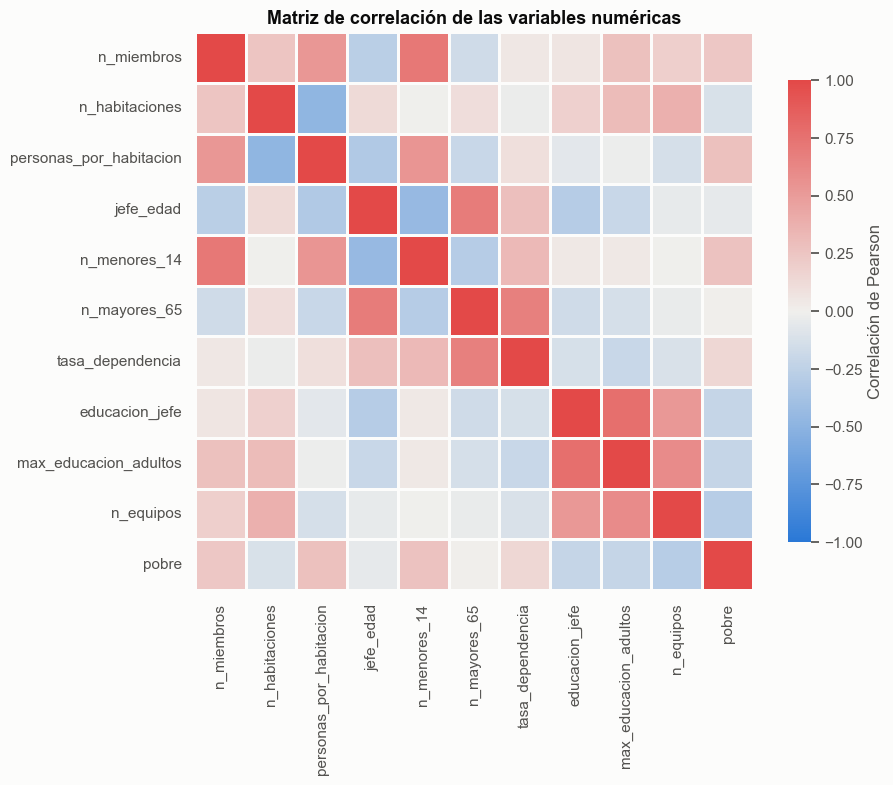

,correlación con pobre
n_equipos,-0.289
educacion_jefe,-0.214
max_educacion_adultos,-0.212
n_habitaciones,-0.121
jefe_edad,-0.048
n_mayores_65,0.005
tasa_dependencia,0.142
n_miembros,0.239
n_menores_14,0.268
personas_por_habitacion,0.277


In [14]:
matriz = hogares[VARIABLES_NUMERICAS + ["pobre"]].corr()

# Escala divergente: azul (negativa) - gris (cero) - rojo (positiva)
divergente = LinearSegmentedColormap.from_list("divergente", ["#2a78d6", "#f0efec", "#e34948"])

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(matriz, cmap=divergente, vmin=-1, vmax=1, center=0, square=True,
            linewidths=2, linecolor="#fcfcfb", cbar_kws={"label": "Correlación de Pearson", "shrink": 0.8}, ax=ax)
ax.set_title("Matriz de correlación de las variables numéricas")
guardar_figura("02_matriz_correlacion")
plt.show()

# Vista de tabla: correlación de cada variable con la variable objetivo
matriz["pobre"].drop("pobre").sort_values().round(3).to_frame("correlación con pobre")

### ¿Qué evidencia proporciona este gráfico?

- **Correlación con la pobreza:**
  - positiva: personas por habitación (0,277), menores de 14 años (0,268), miembros del hogar (0,239) y tasa de dependencia (0,142);
  - negativa: número de artefactos (−0,289) y educación del jefe(a) (−0,214) o de los adultos (−0,212).
- **Todas las correlaciones son moderadas o débiles** (menores a 0,3 en valor absoluto). Ninguna variable numérica por sí sola explica la pobreza, lo que refuerza la necesidad de un modelo multivariable.
- **Correlaciones fuertes entre predictoras:** educación del jefe(a) y máxima educación de los adultos (0,77), miembros y menores de 14 años (0,71), y edad del jefe(a) y mayores de 65 (0,69). Esto no es un problema para Random Forest ni para los árboles. En la regresión logística puede hacer que los coeficientes individuales sean menos estables, pero no afecta su capacidad predictiva, que es lo que evaluamos.
- La correlación de Pearson solo mide **relaciones lineales**. Los boxplots mostraron relaciones que podrían no serlo, lo que justifica comparar un modelo lineal (regresión logística) con modelos no lineales (árbol, KNN y Random Forest).

## 6. Evidencia del problema: errores de focalización en programas sociales

Esta sección **no aporta variables al modelo**. Aporta **evidencia de la situación problemática**: ¿los programas sociales llegan a quienes deberían llegar? Usamos el módulo 700 de la ENAHO, donde el jefe(a) del hogar declara si recibe **Juntos** (transferencias a hogares pobres con niños o gestantes) o **Pensión 65** (adultos mayores en pobreza extrema).

In [15]:
# Esta sección usa dos módulos originales: sumaria (34) y programas sociales (37).
# Si ya se descargaron en el cuaderno 01, no se vuelven a descargar.
descargar_enaho(anio=2025, modulos=["34", "37"])
modulos = cargar_modulos(anio=2025, nombres=["programas", "sumaria"])
programas, sumaria = modulos["programas"], modulos["sumaria"]

# Beneficiarios actuales: programa vigente "hasta la actualidad" o recibido en 2025
vigente = programas[(programas["P713E"] == 1) | (programas["P713D"] >= 2025)]

filas = []
for codigo, nombre in [(4, "Juntos"), (5, "Pensión 65")]:
    beneficiarios = vigente[vigente["P712"] == codigo][CLAVES_HOGAR].drop_duplicates().assign(recibe=1)
    datos = sumaria.merge(beneficiarios, on=CLAVES_HOGAR, how="left")
    recibe = datos["recibe"].fillna(0) == 1
    es_pobre = datos["POBREZA"] <= 2
    peso = datos["FACTOR07"]  # peso de hogares
    filas.append({
        "programa": nombre,
        "hogares_beneficiarios_muestra": int(recibe.sum()),
        "beneficiarios_no_pobres_%": ((recibe & ~es_pobre) * peso).sum() / (recibe * peso).sum() * 100,
        "hogares_pobres_que_lo_reciben_%": ((recibe & es_pobre) * peso).sum() / (es_pobre * peso).sum() * 100,
    })

focalizacion = pd.DataFrame(filas).set_index("programa").round(1)
focalizacion

,hogares_beneficiarios_muestra,beneficiarios_no_pobres_%,hogares_pobres_que_lo_reciben_%
programa,,,
Juntos,3736,59.3,18.1
Pensión 65,3647,69.0,13.6


### ¿Qué evidencia proporciona esta tabla?

Con estimaciones ponderadas a nivel nacional:

- El **59,3 % de los hogares que reciben Juntos** y el **69,0 % de los que reciben Pensión 65** **no son pobres** según la medición oficial del INEI.
- Solo el **18,1 %** de los hogares pobres recibe Juntos y el **13,6 %** recibe Pensión 65.

**Precauciones al interpretar estas cifras** (se discutirán en las amenazas a la validez del informe):

1. **Efecto de la propia transferencia:** la pobreza se mide *después* de recibir el programa, así que parte de los beneficiarios "no pobres" podrían haber salido de la pobreza gracias a la transferencia.
2. **Distintos criterios de elegibilidad:** Juntos exige tener niños o gestantes y Pensión 65 exige tener 65 años o más, así que no todos los hogares pobres son elegibles para cada programa.
3. **Distinto concepto de pobreza:** los programas usan la clasificación socioeconómica del SISFOH, basada en características del hogar, y no el gasto medido por la ENAHO.

Aun con estas precauciones, la magnitud de las cifras indica que **identificar correctamente a los hogares pobres es un problema real y difícil**. Esa es la necesidad que este proyecto aborda: **evaluar si un modelo de aprendizaje automático basado en características observables identifica mejor a los hogares pobres que una regla simple**.

## Conclusiones del análisis exploratorio

1. **Desbalance moderado** (18,1 % de hogares pobres): obliga a división estratificada, a métricas más allá del accuracy y a considerar el balanceo de clases.
2. **Fuerte heterogeneidad geográfica** (de 4,5 % a 41,0 % por departamento): la ubicación es informativa, pero exige evaluar si el modelo es justo entre regiones.
3. **La vivienda, los servicios, el equipamiento, la educación y la composición del hogar se asocian con la pobreza**, pero **ninguna variable aislada separa las clases**. Esto justifica un modelo que combine muchas características.
4. **La regla "rural = pobre" es insuficiente**, porque una parte importante de la pobreza es urbana. Esa regla será el baseline sin IA.
5. **Los valores atípicos son reales** y se conservan. Las correlaciones fuertes entre algunas predictoras no impiden el modelado.
6. **Existe evidencia de errores de focalización** en los programas sociales, lo que respalda la relevancia práctica del problema.

**Siguiente paso:** cuaderno `03_preprocessing.ipynb`, donde se define el pipeline de preparación, la división entrenamiento/prueba y las medidas contra el *data leakage*.